<a href="https://colab.research.google.com/github/fahimaislam2022/Python-/blob/main/2A_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Polynomial Regression

Polynomial Regression is the same as Linear Regression but we're adding polynomial features to the dataset. For instance if we have two features $x_1$, and $x_2$. We'll add $x_1^2$, $x_2^2$, $x_1x_2$, $x_1^3$ and so on. Adding these features will give us a non-linear fit, i.e. a boundary that's not simple plain line.

In [2]:
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import minimize

df = pd.read_csv('/content/ex2data2.csv', header=None)
df.rename(columns={0: 'chip1', 1: 'chip2', 2:'y'}, inplace=True)
df.head()

,chip1,chip2,y
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


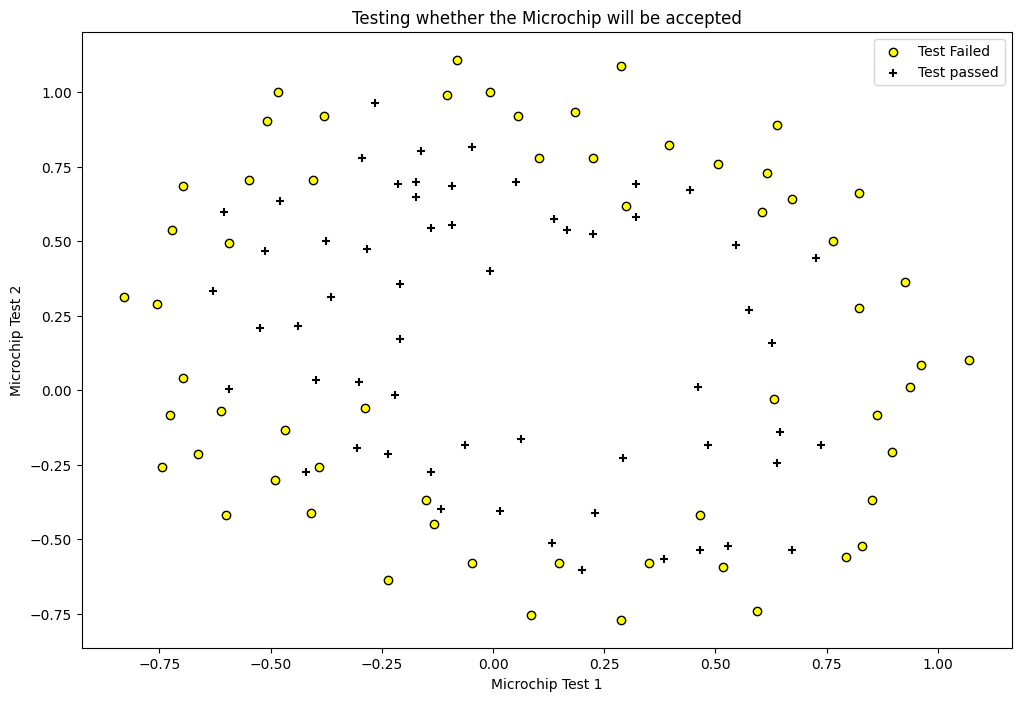

In [4]:
fig = plt.figure(figsize=(12, 8))
plt.scatter(df[df['y'] ==0]['chip1'], df[df['y'] == 0]['chip2'], label='Test Failed', color='yellow', edgecolor='black')
plt.scatter(df[df['y'] == 1]['chip1'], df[df['y'] == 1]['chip2'], label='Test passed', marker='+', color='black')
plt.xlabel('Microchip Test 1')
plt.ylabel('Microchip Test 2')
plt.legend(loc='upper right')
plt.title('Testing whether the Microchip will be accepted')
plt.show()

In [6]:
class LogisticRegression(object):
  def __init__(self, x, y, alpha=0.001, n_iterations=5000, lambda_param=0, verbose=True):
    self.y = self._handle_data_type(y)
    self.x = self._handle_data_type(x)
    self.x = self._hstack_one(x)
    self.thetas = np.zeros((self.x.shape[1]))
    self.n_rows = self.x.shape[0]
    self.n_features = self.thetas.shape[0]
    self.alpha = alpha
    self.n_iterations = n_iterations
    self.lambda_param = lambda_param
    if verbose:
      print("Number Of features: {0}".format(self.n_features -1))
      print("Cost before fitting: {0:.4f}".format(self.cost()))

  @staticmethod
  def _handle_data_type(new_X):
    return new_X

  @staticmethod
  def _hstack_one(input_matrix):
    if len(input_matrix.shape) == 1:
      return np.hstack((np.array([1]), input_matrix))

    else:
      return np.hstack((np.ones((input_matrix.shape[0], 1)), input_matrix))

  @staticmethod
  def sigmoid(x):
    return 1 / (1 + np.exp(-x))

  def cost(self, thetas=None):
      if thetas is None:
          thetas = self.thetas
      dot_prod = self.x.dot(thetas)
      dot_prod_pos = dot_prod[self.y == 1]
      dot_prod_neg = dot_prod[self.y == 0]

      cost = -(1/self.n_rows) * (np.sum(np.log(self.sigmoid(dot_prod_pos))) \
                               + np.sum(np.log(1 - self.sigmoid(dot_prod_neg)))) \
                               + (self.lambda_param/(2*self.n_rows)) \
                               * np.sum(self.thetas[1:]**2)
      return cost

  def predict(self, new_x, threshold=0.5):
    new_x = self._handle_data_type(new_x)
    assert new_x.shape[0] != self.x.shape[1], \
 "Number of features dont match. {0} != {1}".format(new_x.shape[1], self.x.shape[1])
    new_x = self._hstack_one(new_x)
    h = new_x.dot(self.thetas)
    results = self.sigmoid(h) >= threshold
    return results

  def batch_gradient(self, thetas=None):
    if thetas is None:
      thetas = self.thetas
    h = self.sigmoid(self.x.dot(thetas)) - self.y
    h = np.multiply(self.x, h.reshape(-1, 1))
    h = np.sum(h, axis=0)
    reg = thetas * self.lambda_param
    reg[0] = 0
    h +=reg
    return h

  def batch_gradient_descent(self, ):
    alpha_by_m = self.alpha/self.n_rows
    for i in range(self.n_iterations):
      self.thetas = self.thetas - (alpha_by_m * self.batch_gradient())
      cost = self.cost()
      print ("\rIteration: {0} Loss: {1:.5f}".format(i + 1, cost) + "")

  def scipy_optimize(self, verbose=True):
    result = minimize(self.cost, self.thetas, jac=self.batch_gradient, options={'maxiter': self.n_iterations})
    if verbose:
      print(result)
    self.thetas = result.x

### Simple Logistic Regression

In [7]:
simple_lr = LogisticRegression(df[['chip1','chip2']].values, df['y'].values, n_iterations=20000)
simple_lr.scipy_optimize()

Number Of features: 2
Cost before fitting: 0.6931
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.69024112201698
        x: [-1.418e-02 -3.035e-01 -1.813e-02]
      nit: 48
      jac: [-8.121e-06 -5.796e-07 -1.105e-06]
 hess_inv: [[ 3.955e-02 -1.163e-02 -2.684e-02]
            [-1.163e-02  1.452e-01  2.196e-02]
            [-2.684e-02  2.196e-02  1.432e-01]]
     nfev: 165
     njev: 165


In [ ]:
def plot(col1, col2, clf):
  min_ex1 = df[col1].min()
  max_ex1 = df[col1].max()

  min_ex2 = df[col2].min()
  max_ex2 = df[col2].max()

  arange_step = 0.001

  xx, yy = np.meshgrid(np.arange(min_ex1, max_ex1, arange_step), np.arange(min_ex2, max_ex2, arange_step))
  preds = np.c_[xx.ravel(), yy,rave]